# Graph internal PII

- **Human** message stays in `state.messages` (original email).
- Each LLM node **appends** an **AI** message (raw JSON string) for the trace.
- Structured results live in **`pii_email`** and **`todo_list`** on `GlobalState`.
- `BaseReducerReader` only **observes** and vaults message copies — it does not redact.

Re-run graph + invoke cells after edits. 

In [7]:
import sys

# See README.md - only valid for devcontainer workflow!
sys.path.insert(0, "/workspace")

from typing import Annotated, Callable

from src.reducer.base_reader import BaseReducerReader

from langgraph.graph import END, START, StateGraph
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import convert_to_openai_messages
from pydantic import BaseModel, Field, ValidationError
from IPython.display import Image, display
from src.reducer.reducer_session import (
    reducer_session,
    session_message_reducer,
)
from src.llm_handle.local import get_async_openai_client
import json


Prompts

In [8]:
MODEL = "ollama_chat/llama3.2:3b"

pii_email = """
This is a confidental email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date for both tasks is today.
"""

# email_domain_valid = ["ourcompany.com"]

pii_extract_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            You are a deterministic text transformer. Do not chat, explain, or fix spelling.

Task: Copy the user text verbatim except email addresses.
Email = typical address (user@domain.tld) or spelled-out variants ("user at domain dot com").
Replace in order of first appearance: 1st → EMAIL0, 2nd → EMAIL1, 3rd → EMAIL2, ...

Rules:
- Change ONLY email-like spans. Keep all other words, punctuation, and line breaks.
- "emails" = original addresses in order (normalized, e.g. ulf.wendel@phpdoc.de).
- If zero emails: {{"text": "<unchanged input>", "emails": []}}

Output: a single JSON object only. No markdown, no prose, no code fences.

Fields:
- text (string): transformed text with EMAIL0, EMAIL1, ...
- emails (array of strings): originals in order

Example input:
Task alice@x.com and bob@test.org today.
Example output:
{{"text": "Task EMAIL0 and EMAIL1 today.", "emails": ["alice@x.com", "bob@test.org"]}}
            """
        ),
        ("user", "{input}"),
    ]
)

todo_list_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            You are a deterministic TODO list extractor. Do not chat, explain, or fix spelling.

Task: Extract TODO items from the user text. Each item: who, what, when.
- who: person or token (e.g. EMAIL0). If unclear, "UNKNOWN".
- when: deadline if stated. If unclear, "UNKNOWN".

Output: a single JSON object only. No markdown, no prose, no code fences.

Fields:
- items: array of objects with keys who, what, when (all strings)

Example input:
Task EMAIL0 and Bob to feed the cat today.
Example output:
{{"items": [{{"who": "EMAIL0", "what": "feed the cat", "when": "today"}}, {{"who": "Bob", "what": "feed the cat", "when": "today"}}]}}
            """
        ),
        ("user", "{input}"),
    ]
)

State

In [ ]:
def make_reader(get_thread_id: Callable[[], str]):
    return BaseReducerReader(get_thread_id=get_thread_id)

class PIIEmail(BaseModel):
    text: str = Field(default="")
    emails: list[str] = Field(default_factory=list)

class TODOItem(BaseModel):
    who: str = Field(default="")
    what: str = Field(default="")
    when: str = Field(default="")

class TODOList(BaseModel):
    items: list[TODOItem] = Field(default_factory=list)

class GlobalState(BaseModel):
    messages: Annotated[list[BaseMessage], session_message_reducer] = Field(
        default_factory=list
    )
    pii_email: PIIEmail = Field(default_factory=PIIEmail)
    todo_list: TODOList = Field(default_factory=TODOList)

Graph

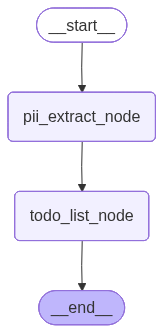

In [10]:
def _parse_llm_json(answer: str, model_cls):
    raw = (answer or "").strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[-1].rsplit("```", 1)[0].strip()
    try:
        return model_cls.model_validate(json.loads(raw))
    except json.JSONDecodeError as e:
        raise ValueError(f"Invalid JSON from model: {e}") from e
    except ValidationError as e:
        raise ValueError(f"JSON does not match schema: {e}") from e


class LlmNodeTODOList:
    def __init__(self, model: str, template: ChatPromptTemplate):
        self._client = get_async_openai_client()
        self._model = model
        self._template = template

    async def __call__(self, state: GlobalState) -> dict:
        print(state.pii_email)
        if not state.pii_email.text:
            raise ValueError("Expected non-empty text")
            
        input_text = state.pii_email.text
        
        prompt_value = self._template.invoke({"input": input_text})
        openai_messages = convert_to_openai_messages(prompt_value.messages)
        completion = await self._client.chat.completions.create(
            model=self._model,
            messages=openai_messages,
            temperature=0.0,
        )   
        answer = completion.choices[0].message.content or ""
        parsed = _parse_llm_json(answer, TODOList)

        return {
            "messages": [AIMessage(content=answer.strip())],
            "todo_list": parsed,
        }

class LlmNodePIIExtract:
    def __init__(self, model: str, template: ChatPromptTemplate):
        self._client = get_async_openai_client()
        self._model = model
        self._template = template

    async def __call__(self, state: GlobalState) -> dict:
        last_human = next(
            (m for m in reversed(state.messages) if m.type == "human"),
            None,
        )
        if last_human is None or not isinstance(last_human.content, str):
            raise ValueError("Expected at least one human message with string content")

        prompt_value = self._template.invoke({"input": last_human.content})
        openai_messages = convert_to_openai_messages(prompt_value.messages)
        completion = await self._client.chat.completions.create(
            model=self._model,
            messages=openai_messages,
            temperature=0.0,
        )
        answer = completion.choices[0].message.content or ""
        parsed = _parse_llm_json(answer, PIIEmail)

        return {
            "messages": [AIMessage(content=answer.strip())],
            "pii_email": parsed,
        }


build_graph = StateGraph(GlobalState)

build_graph.add_node(
    "todo_list_node", 
    LlmNodeTODOList(model=MODEL, template=todo_list_prompt))
build_graph.add_node(
    "pii_extract_node",
    LlmNodePIIExtract(model=MODEL, template=pii_extract_prompt),
)

build_graph.add_edge(START, "pii_extract_node")
build_graph.add_edge("pii_extract_node", "todo_list_node")
build_graph.add_edge("todo_list_node", END)

graph = build_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

Invoke

In [ ]:
reducer = None
with reducer_session("Chat-ABC", factory=make_reader) as session:

    print("")
    print("--- first turn ---")
    print("")

    reducer = session.reducer

    state = session.state(GlobalState, [HumanMessage(content=pii_email)])
    reply = await session.ainvoke(graph, state)

    state = GlobalState.model_validate(reply)
    for m in state.messages:
        if hasattr(m, "content") and isinstance(m.content, str):
            print(f"\tREPLY: {m.type}: {m.content}")

    print(f"\tPII: {state.pii_email}")
    print(f"\tTODO: {state.todo_list}")



--- first turn ---

REDUCER (thread=Chat-ABC): observing message content: 
This is a confidental email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date for both tasks is today.

REDUCER (thread=Chat-ABC): observing message content: {"text": "Task EMAIL0 to buy a cup of coffee, and EMAIL1 needs to reach out to all employees regarding the current coffee shortage as it is demotivating our technical staff.", "emails": ["ulf.wendel@ phpdoc dot de", "cto@ourcompany.com"]}
text='Task EMAIL0 to buy a cup of coffee, and EMAIL1 needs to reach out to all employees regarding the current coffee shortage as it is demotivating our technical staff.' emails=['ulf.wendel@ phpdoc dot de', 'cto@ourcompany.com']
REDUCER (thread=Chat-ABC): observing message content: {"items": [{"who": "EMAIL0", "what": "buy a cup of coffee"}, {"who": "EMAIL1", "what":

Vault

In [12]:

print("--- vault: your audit log  ---")
print("")
vault = reducer.get_vault_for_thread("Chat-ABC")
for k, v in vault.get():
    print(f"{k}: {v}")

reducer.reset_all()

--- vault: your audit log  ---

None: content='\nThis is a confidental email.\n\nTask ulf.wendel@ phpdoc dot de to buy a cup of coffee,\nand cto@ourcompany.com needs to reach out to all employees \nregarding the current coffee shortage as it is demotivating our technical staff.\nDue date for both tasks is today.\n' additional_kwargs={} response_metadata={}
None: content='{"text": "Task EMAIL0 to buy a cup of coffee, and EMAIL1 needs to reach out to all employees regarding the current coffee shortage as it is demotivating our technical staff.", "emails": ["ulf.wendel@ phpdoc dot de", "cto@ourcompany.com"]}' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
None: content='{"items": [{"who": "EMAIL0", "what": "buy a cup of coffee"}, {"who": "EMAIL1", "what": "reach out to all employees", "when": "regarding the current coffee shortage"}]}' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
